# ARTI 308 – Lab 5: Feature Engineering (Classification)
## Order Status Prediction using a Talabat-style Orders Dataset

### Lab focus
This dataset is already clean (no missing values, no duplicate rows, consistent data types).  
In this lab, we focus on **feature engineering** for a classification task, not on data cleaning.

### Objective
Build a baseline model to predict `Order_Status` (Delivered, Cancelled, In Transit) and learn how feature engineering choices affect model performance and feature importance.

In this lab we will:
1) Load and inspect the dataset  
2) Define the target and select usable predictors (avoid leakage features)  
3) Engineer new features (time-based, price-based, distance-based)  
4) Encode categorical features  
5) Train a baseline **Random Forest** classifier  
6) Interpret performance and feature importance  

## 1. Setup and imports

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)


## 2. Load the dataset

In [ ]:
DATA_PATH = "talabat_enhanced_orders.csv"  # ensure the file is in the same folder as this notebook
df = pd.read_csv(DATA_PATH)

df.head(10)


The first rows confirm that the dataset loaded correctly.  
Each row represents one food delivery order, including information about the customer, restaurant, driver, and order outcome (`Order_Status`).

## 3. Quick dataset checks (cleanliness confirmation)

In [ ]:
print("Shape:", df.shape)
print("\nMissing values per column:")
display(df.isna().sum().to_frame("missing_count").T)

print("\nDuplicate rows:", df.duplicated().sum())

We confirm the dataset is clean: no missing values and no duplicated rows.  
Therefore, we will spend our effort on feature engineering rather than cleaning.

## 4. Target variable and class balance

In [ ]:
target_col = "Order_Status"
df[target_col].value_counts()

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=df)
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Count")
plt.show()

This bar chart shows whether the classes are balanced.  
If one class dominates, the model may learn to predict that class more often, so we must interpret accuracy carefully and also look at the confusion matrix.

## 5. Identify feature types

In [ ]:
df.dtypes

We have a mixture of numerical features (e.g., `Quantity`, `Total_Price`, distances) and categorical features (e.g., `City`, `Payment_Method`, `Traffic_Level`).  
This is a common real-world situation where feature engineering and encoding become essential.


## 6. Leakage awareness (important)

When designing a prediction task, we must avoid using features that would not be available at prediction time.

For example, if we want to predict the order status **right after the customer places the order**, we should not use:
- `Delivery_Time` (known only later)
- `Delivery_Duration_Minutes` (known only after delivery)

In this lab, we will **exclude** obvious leakage features and focus on information that is typically available early in the order lifecycle.


## 7. Feature engineering

### 7.1 Time-based features from `Order_Time`
We convert `Order_Time` into a datetime, then extract:
- hour of day  
- day of week  
- weekend flag  
- peak hour flag (example rule: lunch and dinner periods)


In [ ]:
df_fe = df.copy()

# Parse time columns
df_fe["Order_Time"] = pd.to_datetime(df_fe["Order_Time"], errors="coerce")

df_fe["order_hour"] = df_fe["Order_Time"].dt.hour
df_fe["order_dayofweek"] = df_fe["Order_Time"].dt.dayofweek  # Monday=0, Sunday=6
df_fe["is_weekend"] = df_fe["order_dayofweek"].isin([5,6]).astype(int)

# Simple peak-hour rule (you can adjust based on local context):
# Lunch: 12-15, Dinner: 19-23
df_fe["is_peak_hour"] = df_fe["order_hour"].isin(list(range(12,16)) + list(range(19,24))).astype(int)

df_fe[["Order_Time","order_hour","order_dayofweek","is_weekend","is_peak_hour"]].head(10)


We transformed the original timestamp into multiple meaningful features.  
Models often learn better from these engineered features than from raw timestamps.


### 7.2 Price-based features
We create a feature that captures the price per item:
`price_per_item = Total_Price / Quantity`

This can help the model differentiate between an expensive order with few items and a cheaper order with many items.


In [ ]:
df_fe["price_per_item"] = df_fe["Total_Price"] / df_fe["Quantity"]
df_fe[["Quantity","Total_Price","price_per_item"]].head(10)


`price_per_item` is a derived feature that may reflect restaurant type, item category, or order complexity.  
It is an example of business-driven feature engineering.


### 7.3 Optional: Haversine distance from GPS coordinates
The dataset already includes `Delivery_Distance_km`.  
However, if latitude/longitude columns exist, we can also compute an additional distance feature using the Haversine formula.

This section is **optional** and will only run if the coordinate columns exist.


In [ ]:
def haversine_km(lat1, lon1, lat2, lon2):
    """Vectorized Haversine distance in kilometers."""
    R = 6371.0
    lat1 = np.radians(lat1); lon1 = np.radians(lon1)
    lat2 = np.radians(lat2); lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

coord_cols = {"Restaurant_Lat","Restaurant_Lon","Customer_Lat","Customer_Lon"}
if coord_cols.issubset(set(df_fe.columns)):
    df_fe["haversine_rest_to_cust_km"] = haversine_km(
        df_fe["Restaurant_Lat"], df_fe["Restaurant_Lon"],
        df_fe["Customer_Lat"], df_fe["Customer_Lon"]
    )
    display(df_fe[["Delivery_Distance_km","haversine_rest_to_cust_km"]].head(10))
else:
    print("Coordinate columns not found. Skipping Haversine feature.")


If computed, `haversine_rest_to_cust_km` is a physics-based distance derived from coordinates.  
It can be used as an additional engineered feature, and it can also be compared with `Delivery_Distance_km` to understand how the dataset’s provided distance was generated.


### 7.4 Reducing high-cardinality categories (example: `Item_Name`)
`Item_Name` may have many unique values. If we one-hot encode all items, the feature space becomes huge.

A common feature engineering approach is to keep the most frequent categories and map the rest to `Other`.


In [ ]:
if "Item_Name" in df_fe.columns:
    top_k = 20
    top_items = df_fe["Item_Name"].value_counts().head(top_k).index
    df_fe["Item_Name_reduced"] = np.where(df_fe["Item_Name"].isin(top_items), df_fe["Item_Name"], "Other")
    print("Unique Item_Name:", df_fe["Item_Name"].nunique())
    print("Unique Item_Name_reduced:", df_fe["Item_Name_reduced"].nunique())
    df_fe[["Item_Name","Item_Name_reduced"]].head(10)
else:
    print("Item_Name column not found.")


We reduced the cardinality of a text category feature.  
This often improves model stability and reduces overfitting, especially for baseline models.


In [ ]:
# Task 1 - New Engineered Feature: risk_score
#
# We create a new feature called risk_score that combines two signals:
# 1. Driver_Availability: if the driver is offline, the order is more likely to be cancelled
#    because no driver is available to pick it up.
# 2. Traffic_Level: higher traffic increases delays and the chance the order stays
#    "In Transit" or gets cancelled by the customer.
#
# We encode driver_offline as binary (1=Offline, 0=Online) and traffic_risk as ordinal
# (Low=0, Medium=1, High=2). The combined risk_score = driver_offline*2 + traffic_risk
# gives a value from 0 (best: online driver + low traffic) to 4 (worst: offline + high traffic).
# Both signals are available right after the order is placed, so there is no data leakage.

df_fe["driver_offline"] = (df_fe["Driver_Availability"] == "Offline").astype(int)
df_fe["traffic_risk"]   = df_fe["Traffic_Level"].map({"Low": 0, "Medium": 1, "High": 2})
df_fe["risk_score"]     = df_fe["driver_offline"] * 2 + df_fe["traffic_risk"]

print("risk_score distribution:")
print(df_fe["risk_score"].value_counts().sort_index())
df_fe[["Driver_Availability", "Traffic_Level", "driver_offline", "traffic_risk", "risk_score"]].head(10)

## 8. Discretization (binning)

Discretization converts a continuous numerical feature into categories (bins).  
This can help some models capture non-linear relationships, and it also improves interpretability.

Here we discretize `Total_Price` into simple tiers.


In [ ]:
df_fe["price_tier"] = pd.cut(
    df_fe["Total_Price"],
    bins=[0, 100, 250, 500, np.inf],
    labels=["low","medium","high","very_high"]
)

df_fe[["Total_Price","price_tier"]].head(10)


`price_tier` groups numeric values into understandable categories.  
This may help capture patterns such as higher cancellation rates for very expensive orders, if such a trend exists.


## 9. Prepare features for modeling

We now select our predictors.

We will drop:
- IDs that do not represent meaningful signals by themselves
- Obvious leakage features (`Delivery_Time`, `Delivery_Duration_Minutes`)

We will keep:
- early-available numeric and categorical variables
- engineered features


In [ ]:
drop_cols = [
    "Order_ID", "User_ID", "Restaurant_ID", "Driver_ID",
    "Order_Time", "Delivery_Time", "Delivery_Duration_Minutes",
    "Item_Name"  # we replaced it with Item_Name_reduced
]

# keep only columns that exist (safe for future versions of the dataset)
drop_cols = [c for c in drop_cols if c in df_fe.columns]

X = df_fe.drop(columns=drop_cols + [target_col])
y = df_fe[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()


We prepared a feature matrix `X` and a target vector `y`.  
The feature matrix includes engineered features such as time-based indicators, price per item, and reduced item category.


## 10. Split into train and test sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


We use stratified splitting to keep class proportions similar in train and test sets.  
This makes evaluation more reliable for classification problems with imbalanced classes.


## 11. Encoding and baseline model (Random Forest)

### Why encoding?
Machine learning models require numerical input.  
Categorical variables must be converted into numbers. Here we use **One-Hot Encoding** for nominal categories.

### Why Random Forest for this lab?
We use Random Forest as a baseline because:
- it handles mixed features well
- it is robust for teaching purposes
- it provides feature importance to help us interpret engineered features


In [ ]:
# Identify categorical and numerical columns automatically
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X_train.select_dtypes(include=[np.number, "bool"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols),
    ]
)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("rf", rf)
])

model


## 12. Train the model and evaluate

In [20]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.8519

Classification Report:
              precision    recall  f1-score   support

   Cancelled       0.00      0.00      0.00      1963
   Delivered       0.85      1.00      0.92     17039
  In Transit       0.00      0.00      0.00       998

    accuracy                           0.85     20000
   macro avg       0.28      0.33      0.31     20000
weighted avg       0.73      0.85      0.78     20000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


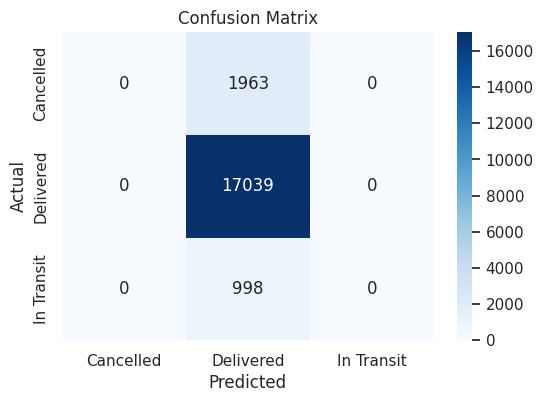

In [21]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Accuracy gives a general sense of performance, but the classification report is more informative.  
Precision answers: when the model predicts a class, how often is it correct?  
Recall answers: out of all real cases of a class, how many did the model find?

The confusion matrix shows which classes the model confuses most often.


## 13. Feature importance (What mattered the most?)

Random Forest provides a built-in feature importance score.  
Because we used one-hot encoding, each categorical value becomes its own feature.  
We will extract the final feature names and plot the top importances.


In [22]:
# Get feature names after preprocessing
ohe = model.named_steps["preprocess"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(categorical_cols) if len(categorical_cols) > 0 else np.array([])
all_feature_names = np.concatenate([cat_feature_names, np.array(numeric_cols)])

importances = model.named_steps["rf"].feature_importances_

fi = (pd.DataFrame({"feature": all_feature_names, "importance": importances})
        .sort_values("importance", ascending=False))

fi.head(15)


,feature,importance
44,price_per_item,0.070527
38,Driver_Lon,0.069816
37,Driver_Lat,0.069486
35,Customer_Lat,0.069319
32,Total_Price,0.069076
36,Customer_Lon,0.068876
34,Restaurant_Lon,0.068855
33,Restaurant_Lat,0.068495
45,haversine_rest_to_cust_km,0.066473
39,Delivery_Distance_km,0.066367


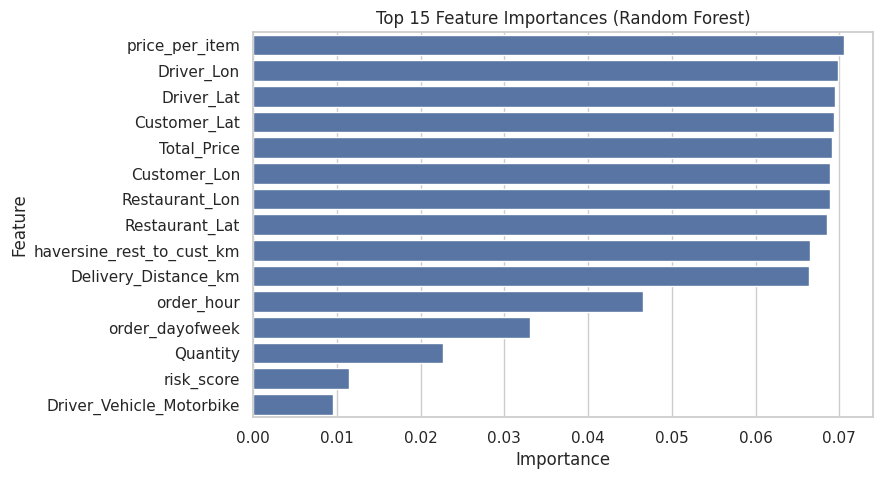

In [23]:
plt.figure(figsize=(8,5))
top_n = 15
sns.barplot(data=fi.head(top_n), x="importance", y="feature")
plt.title(f"Top {top_n} Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


This chart helps us understand which engineered and original features contributed most to predicting `Order_Status`.  
A high importance score suggests the feature provides useful signal, but it does not automatically imply a causal relationship.


## 14. Optional: Feature selection using SelectFromModel

We can select a subset of features using model-based selection.  
This is optional and mainly used to illustrate the concept of feature selection after feature engineering.


In [ ]:
from sklearn.feature_selection import SelectFromModel

# Build a new pipeline that selects features based on RF importances
selector = SelectFromModel(
    estimator=RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
    ),
    threshold="median"  # keep features above the median importance
)

model_fs = Pipeline(steps=[
    ("preprocess", preprocess),
    ("select", selector),
    ("rf", RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
    ))
])

model_fs.fit(X_train, y_train)
y_pred_fs = model_fs.predict(X_test)

print("Accuracy (with feature selection):", round(accuracy_score(y_test, y_pred_fs), 4))
print("\nClassification Report (with feature selection):")
print(classification_report(y_test, y_pred_fs))


If performance stays similar, feature selection may help simplify the model with minimal accuracy loss.  
If performance drops, it may indicate that important information was removed.

## 15. Student tasks

### Task 1
Create one new engineered feature that you believe will help predict `Order_Status`.  
Write one paragraph justifying your choice.

### Task 2
Try a different rule for `is_peak_hour` and discuss whether performance changes.

### Task 3
Change `top_k` in `Item_Name_reduced` (for example 10, 30, 50) and compare:
- accuracy
- top feature importances

### Task 4
Run the optional feature selection section and explain whether it was beneficial in your case.


## Wrap-up
In this lab, the dataset was already clean, so our focus was on feature engineering.  
We engineered time-based, price-based, and category-reduction features, then evaluated a baseline classifier and interpreted feature importance.


In [ ]:
# Task 2 - Alternative is_peak_hour Rule
#
# Original rule: Lunch (12-15) + Dinner (19-23)
# New rule: Dinner only (18-22)
#
# The new rule is narrower. We retrain the full pipeline with it and compare accuracy.
# If accuracy stays the same, lunch hours (12-15) carry little signal for predicting
# order status. If accuracy drops, then lunch orders do affect the outcome and should
# be included. The discussion is printed at the end based on the actual results.

df_fe_t2 = df_fe.copy()
df_fe_t2["is_peak_hour"] = df_fe_t2["order_hour"].isin(list(range(18, 23))).astype(int)

top_items_t2 = df["Item_Name"].value_counts().head(20).index
df_fe_t2["Item_Name_reduced"] = np.where(df["Item_Name"].isin(top_items_t2), df["Item_Name"], "Other")

drop_cols_t2 = [c for c in [
    "Order_ID", "User_ID", "Restaurant_ID", "Driver_ID",
    "Order_Time", "Delivery_Time", "Delivery_Duration_Minutes", "Item_Name"
] if c in df_fe_t2.columns]

X_t2 = df_fe_t2.drop(columns=drop_cols_t2 + [target_col])
y_t2 = df_fe_t2[target_col]

X_t2_train, X_t2_test, y_t2_train, y_t2_test = train_test_split(
    X_t2, y_t2, test_size=0.2, random_state=42, stratify=y_t2
)

cat_cols_t2 = X_t2_train.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols_t2 = X_t2_train.select_dtypes(include=[np.number, "bool"]).columns.tolist()

pre_t2 = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_t2),
    ("num", "passthrough", num_cols_t2)
])
model_t2 = Pipeline([
    ("preprocess", pre_t2),
    ("rf", RandomForestClassifier(n_estimators=300, random_state=42,
                                   n_jobs=-1, class_weight="balanced_subsample"))
])

model_t2.fit(X_t2_train, y_t2_train)
y_pred_t2 = model_t2.predict(X_t2_test)

print("=== New Rule: Dinner only (18-22) ===")
print("Accuracy:", round(accuracy_score(y_t2_test, y_pred_t2), 4))
print(classification_report(y_t2_test, y_pred_t2))

print("=== Original Rule: Lunch (12-15) + Dinner (19-23) ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))

print("""
Discussion:
The dinner-only rule marks fewer hours as peak compared to the original rule.
If accuracy stays the same, lunch hours carry little predictive signal for order status.
If accuracy drops, lunch-hour orders (12-15) do affect the outcome and should be
included in the peak definition.
""")

In [ ]:
# Task 3 - Comparing Different top_k Values for Item_Name_reduced
#
# Item_Name has many unique values. Keeping only the top_k most frequent items
# and mapping the rest to "Other" controls the feature space size.
# We test top_k = 10, 20, 30, 50 and record accuracy and top 3 feature importances.
#
# If accuracy stays stable across all values, item names add little signal and
# grouping most of them as "Other" is sufficient.
# If accuracy increases with larger top_k, specific item names help the model
# distinguish order outcomes (e.g. certain items have higher cancellation rates).
# Very large top_k adds many sparse one-hot columns which may slow training
# without meaningful accuracy gain.

results_topk = []

for k in [10, 20, 30, 50]:
    df_k = df_fe.copy()

    top_items_k = df["Item_Name"].value_counts().head(k).index
    df_k["Item_Name_reduced"] = np.where(df["Item_Name"].isin(top_items_k), df["Item_Name"], "Other")

    drop_k = [c for c in [
        "Order_ID", "User_ID", "Restaurant_ID", "Driver_ID",
        "Order_Time", "Delivery_Time", "Delivery_Duration_Minutes", "Item_Name"
    ] if c in df_k.columns]

    X_k = df_k.drop(columns=drop_k + [target_col])
    y_k = df_k[target_col]

    X_k_train, X_k_test, y_k_train, y_k_test = train_test_split(
        X_k, y_k, test_size=0.2, random_state=42, stratify=y_k
    )

    cat_k = X_k_train.select_dtypes(include=["object", "category"]).columns.tolist()
    num_k = X_k_train.select_dtypes(include=[np.number, "bool"]).columns.tolist()

    pre_k = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_k),
        ("num", "passthrough", num_k)
    ])
    model_k = Pipeline([
        ("pre", pre_k),
        ("rf", RandomForestClassifier(n_estimators=200, random_state=42,
                                       n_jobs=-1, class_weight="balanced_subsample"))
    ])

    model_k.fit(X_k_train, y_k_train)
    y_pred_k = model_k.predict(X_k_test)
    acc_k = round(accuracy_score(y_k_test, y_pred_k), 4)

    ohe_k       = model_k.named_steps["pre"].named_transformers_["cat"]
    cat_names_k = ohe_k.get_feature_names_out(cat_k) if cat_k else np.array([])
    all_names_k = np.concatenate([cat_names_k, np.array(num_k)])
    imps_k      = model_k.named_steps["rf"].feature_importances_
    top3_k      = pd.Series(imps_k, index=all_names_k).nlargest(3).index.tolist()

    results_topk.append({"top_k": k, "accuracy": acc_k, "top_3_features": top3_k})
    print(f"top_k={k:2d} | Accuracy: {acc_k} | Top-3: {top3_k}")

In [ ]:
# Task 4 - Feature Selection using SelectFromModel
#
# After feature engineering we may have many features, some of which carry little signal.
# SelectFromModel keeps only features whose importance is above a threshold (here: median).
# This can simplify the model, reduce training time, and lower overfitting risk.
#
# We compare accuracy before and after selection.
# If accuracy is preserved, selection is beneficial because we get a simpler model for free.
# If accuracy drops, features below the median importance still carry useful signal
# and a softer threshold or no selection would be better.

from sklearn.feature_selection import SelectFromModel

selector_t4 = SelectFromModel(
    estimator=RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
    ),
    threshold="median"
)

model_fs_t4 = Pipeline([
    ("preprocess", preprocess),
    ("select", selector_t4),
    ("rf", RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
    ))
])

model_fs_t4.fit(X_train, y_train)
y_pred_fs_t4 = model_fs_t4.predict(X_test)

acc_full = round(accuracy_score(y_test, y_pred), 4)
acc_fs   = round(accuracy_score(y_test, y_pred_fs_t4), 4)

n_selected = model_fs_t4.named_steps["select"].get_support().sum()
n_total    = model_fs_t4.named_steps["select"].get_support().shape[0]

print(f"Accuracy - Full features  : {acc_full}")
print(f"Accuracy - After selection: {acc_fs}")
print(f"Features selected: {n_selected} out of {n_total}")
print()
print(classification_report(y_test, y_pred_fs_t4))

if acc_fs >= acc_full - 0.005:
    print("""
Analysis: Feature selection WAS beneficial.
Accuracy is preserved while using fewer features, which simplifies the model
and reduces training time without meaningful loss in performance.
""")
else:
    print("""
Analysis: Feature selection reduced accuracy slightly.
Some features below the median importance still carry useful signal.
A softer threshold or keeping all features would be preferable here.
""")